**#PyTorch Mini Project (Dataset-Independent)**
Choose One Dataset

Students must choose MNIST Handwritten Digit Dataset from the following list and build a PyTorch ANN model.

1️⃣ MNIST Handwritten Digit Dataset

Digits 0–9 classification.

Dataset link:
https://www.kaggle.com/datasets/hojjatk/mnist-dataset


# Topics Students Must Use

Students must apply the following PyTorch concepts in their project:

Why PyTorch

Tensors

Autograd

PyTorch Training Pipeline

torch.nn Module & torch.optim Module

Dataset and DataLoader

Building ANN using PyTorch

Model training and evaluation



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(42)

In [ ]:
from torchvision import datasets

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=None)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=None)

X_train, y_train = train_dataset.data, train_dataset.targets
X_test, y_test = test_dataset.data, test_dataset.targets

In [ ]:
X_train.shape

torch.Size([60000, 28, 28])

In [ ]:
y_test.shape

torch.Size([10000])

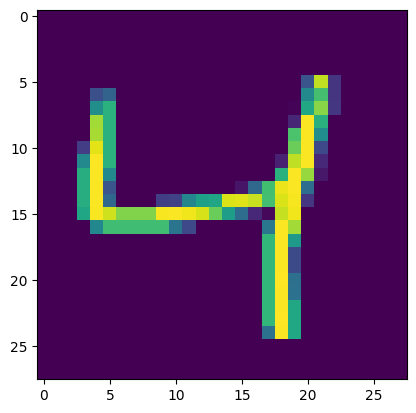

In [ ]:
plt.imshow(X_train[2])

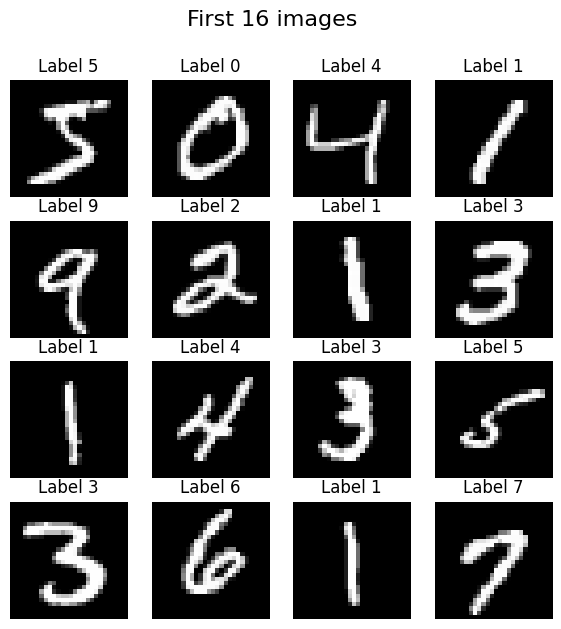

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(7, 7))
fig.suptitle("First 16 images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = X_train[i]          # tensor 28x28
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label {y_train[i].item()}")

plt.show()

In [ ]:
y_train

tensor([5, 0, 4,  ..., 5, 6, 8])

In [ ]:
# Scaling
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
# After scaling
X_train[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

#Write answer of Question 2

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = features
    self.labels = labels
  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    x = self.features[index].view(-1)
    y = self.labels[index]
    return x, y

In [ ]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
len(train_dataset)

60000

In [ ]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True)

# Define NN class
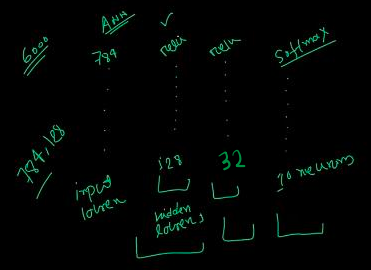

In [ ]:
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
      nn.Linear(num_features, 128),
      nn.ReLU(),
      nn.Linear(128, 32),
      nn.ReLU(),
      nn.Linear(32, 10)
      # Softmax is integrated in CCE(CrossEntropyLoss) Loss function
)

  def forward(self, X):
    return self.model(X.view(-1,784))

### Instatiate Model

In [ ]:
epochs = 10
learning_rate = 0.001

In [ ]:
X_train.shape[0]

60000

In [ ]:
model = MyNN(784)

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

In [ ]:
# Optimizers
optimizer = optim.SGD(model.parameters(), learning_rate)

In [ ]:
print("Batch Number", len(train_loader))

Batch Number 938


In [ ]:
len(train_loader)

938

### Training Loop

In [ ]:
for epoch in range(epochs):
  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    #Forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output, batch_labels)

    # back pass
    optimizer.zero_grad()
    loss.backward()

    #update
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

avg_loss = total_epoch_loss/len(train_loader)
print(avg_loss)

1.002442186511656


# Evalaution

In [ ]:
model.eval()
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs, 1)
    total += batch_labels.shape[0]

    correct += (predicted == batch_labels).sum().item()

accuracy = correct / total
print('Accuracy: ', accuracy)

Accuracy:  0.7692
